In [1]:
!wget https://www.dropbox.com/scl/fi/pjiets75ek3lflqh4yrdz/dataset.zip?rlkey=o0vwk214f902cs3w4b079vbz9&st=fipo0beb&dl=0

!mv dataset.zip?rlkey=o0vwk214f902cs3w4b079vbz9 dataset.zip

!unzip dataset.zip

!rm dataset.zip

流式输出内容被截断，只能显示最后 5000 行内容。
  inflating: dataset/training/09220.png  
  inflating: dataset/training/09222.png  
  inflating: dataset/training/09223.png  
  inflating: dataset/training/09224.png  
  inflating: dataset/training/09225.png  
  inflating: dataset/training/09226.png  
  inflating: dataset/training/09227.png  
  inflating: dataset/training/09232.png  
  inflating: dataset/training/09233.png  
  inflating: dataset/training/09234.png  
  inflating: dataset/training/09235.png  
  inflating: dataset/training/09237.png  
  inflating: dataset/training/09239.png  
  inflating: dataset/training/09240.png  
  inflating: dataset/training/09241.png  
  inflating: dataset/training/09243.png  
  inflating: dataset/training/09244.png  
  inflating: dataset/training/09245.png  
  inflating: dataset/training/09246.png  
  inflating: dataset/training/09248.png  
  inflating: dataset/training/09249.png  
  inflating: dataset/training/09250.png  
  inflating: dataset/training/09251.png  
  infla

In [2]:
# [colab] Setup & scan
import os, re, random, time, math, numpy as np
from pathlib import Path
import pandas as pd
from PIL import Image, UnidentifiedImageError

import torch, torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder

# Set random seed for reproducibility
SEED = 2025
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Fixed paths
ROOT = Path("/content/dataset")
TRAIN_DIR = ROOT/"training"
VAL_DIR   = ROOT/"validation"
TEST_DIR  = ROOT/"test"
CSV_PATH  = ROOT/"label.csv"

assert TRAIN_DIR.is_dir() and VAL_DIR.is_dir() and TEST_DIR.is_dir(), "Missing data directories"
assert CSV_PATH.is_file(), "label.csv not found"
print("Dirs OK:", TRAIN_DIR, VAL_DIR, TEST_DIR)

# Read CSV (two columns: Image ID, Image class)
df = pd.read_csv(CSV_PATH)
id_col  = [c for c in df.columns if c.strip().lower()=="image id"]
cls_col = [c for c in df.columns if c.strip().lower()=="image class"]
if not id_col or not cls_col:
    raise ValueError(f"CSV must contain columns: 'Image ID' and 'Image class'. Current columns: {list(df.columns)}")

df = df.rename(columns={id_col[0]: "image_id", cls_col[0]: "image_class"})
df["image_id"] = df["image_id"].astype(str).str.strip()
# Allow IDs like '001', 'ID-12', etc.; extract the digits as the numeric ID
df["image_id_num"] = df["image_id"].str.extract(r"(\d+)").astype(int)

id2class = dict(zip(df["image_id_num"], df["image_class"]))
print(f"[CSV] rows: {len(df)}, class samples: {df['image_class'].unique()[:8]}")

# Scan images
IMG_EXTS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}
def list_images(folder: Path):
    return [p for p in folder.rglob("*") if p.suffix.lower() in IMG_EXTS]

train_imgs = list_images(TRAIN_DIR)
val_imgs   = list_images(VAL_DIR)
test_imgs  = list_images(TEST_DIR)

# Extract numeric ID from filename/path (prefer stem; if not found, fallback to the last number in the path)
_digit_pat = re.compile(r"(\d+)")
def extract_id_from_path(p: Path):
    m = _digit_pat.search(p.stem)
    if m: return int(m.group(1))
    all_nums = _digit_pat.findall(str(p))
    return int(all_nums[-1]) if all_nums else None

# Audit matching
def audit_split(imgs, name):
    total, ok = len(imgs), 0
    miss = []
    for p in imgs:
        iid = extract_id_from_path(p)
        if iid is not None and iid in id2class:
            ok += 1
        else:
            miss.append(str(p.relative_to(ROOT)))
    print(f"[{name}] images={total}, matched labels={ok}, unmatched={total-ok}")
    if miss[:10]:
        print("  Unmatched examples:", miss[:10])

audit_split(train_imgs, "training")
audit_split(val_imgs,   "validation")
print(f"[test] images={len(test_imgs)} (no labels expected)")

# Fit LabelEncoder (based on labels matched in train+val)
train_classes = [id2class.get(extract_id_from_path(p)) for p in train_imgs]
val_classes   = [id2class.get(extract_id_from_path(p)) for p in val_imgs]
all_classes   = [c for c in (train_classes+val_classes) if c is not None]
if not all_classes:
    raise RuntimeError("No labels matched in training/validation. Please check filename ↔ CSV ID mapping.")

le = LabelEncoder().fit(all_classes)
NUM_CLASSES = len(le.classes_)
print("NUM_CLASSES =", NUM_CLASSES, "| classes preview:", le.classes_[:8])

Dirs OK: /content/dataset/training /content/dataset/validation /content/dataset/test
[CSV] rows: 13596, class samples: ['Homogeneous' 'Speckled' 'Nucleolar' 'Centromere' 'NuMem' 'Golgi']
[training] images=8701, matched labels=8701, unmatched=0
[validation] images=2175, matched labels=2175, unmatched=0
[test] images=2720 (no labels expected)
NUM_CLASSES = 6 | classes preview: ['Centromere' 'Golgi' 'Homogeneous' 'NuMem' 'Nucleolar' 'Speckled']


In [5]:
from typing import Tuple, List, Optional
from pathlib import Path
import time, gc
import torch
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True  # Try not to fail on truncated/corrupted images

# --- Transforms: grayscale -> 3 channels, resize to 224, normalize only ---
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# --- Choose exactly one interpolation per run ---
# Options: "nearest" / "bilinear" / "bicubic"
INTERP_NAME = "bicubic"   # change here for ablations

def _interp_from_name(name: str) -> transforms.InterpolationMode:
    name = name.lower()
    if name == "nearest":
        return transforms.InterpolationMode.NEAREST
    elif name == "bilinear":
        return transforms.InterpolationMode.BILINEAR
    elif name == "bicubic":
        return transforms.InterpolationMode.BICUBIC
    else:
        raise ValueError(f"Unknown interp: {name}")

def make_tfms_tensor_resize(interp_name: str):
    """
    Build a single transform pipeline using a chosen interpolation.
    NOTE:
    - We convert to Tensor BEFORE Resize so that interpolation happens on tensors,
      where we can explicitly control 'antialias' and avoid PIL warnings.
    - For non-NEAREST, we explicitly set antialias=False to keep behavior consistent
      across torchvision versions (and match your requirement).
    """
    interp = _interp_from_name(interp_name)
    resize_kwargs = {"size": (224, 224), "interpolation": interp}
    if interp != transforms.InterpolationMode.NEAREST:
        resize_kwargs["antialias"] = False  # explicitly disable

    return transforms.Compose([
        transforms.Grayscale(num_output_channels=3),
        transforms.ToTensor(),                 # Tensor first -> Resize on tensor
        transforms.Resize(**resize_kwargs),    # same interp for all runs; no PIL antialias
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ])

# ---- Build transforms for the selected interpolation (run one at a time) ----
base_tfms = make_tfms_tensor_resize(INTERP_NAME)

# --- Keep only samples whose numeric ID is in filename AND found in CSV labels ---
def filter_matched(paths: List[Path]):
    kept, dropped = [], []
    for p in paths:
        iid = extract_id_from_path(p)      # depends on your helper defined earlier
        cls = id2class.get(iid, None)      # depends on your id2class mapping
        if iid is not None and cls is not None:
            kept.append(p)
        else:
            dropped.append(p)
    return kept, dropped

train_imgs_kept, train_dropped = filter_matched(train_imgs)  # depends on train_imgs
val_imgs_kept,   val_dropped   = filter_matched(val_imgs)    # depends on val_imgs
print(f"[filter] train kept={len(train_imgs_kept)} dropped={len(train_dropped)} | "
      f"val kept={len(val_imgs_kept)} dropped={len(val_dropped)}")

# --- Datasets (train/val: labeled; test: unlabeled) ---
class LabeledFromCSV(Dataset):
    def __init__(self, paths: List[Path], id2class: dict, label_encoder, transform=None):
        self.paths = paths
        self.id2class = id2class
        self.le = label_encoder
        self.transform = transform

    def __len__(self): return len(self.paths)

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, int]:
        p = self.paths[idx]
        # Use context manager to promptly close file handles (prevents worker hangs)
        with Image.open(p) as im:
            img = im.convert("L")
        if self.transform:
            img = self.transform(img)
        iid = extract_id_from_path(p)
        cls_str = self.id2class[iid]
        y = int(self.le.transform([cls_str])[0])
        return img, y

class TestImageDataset(Dataset):
    def __init__(self, paths: List[Path], transform=None):
        self.paths = paths
        self.transform = transform

    def __len__(self): return len(self.paths)

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, str]:
        p = self.paths[idx]
        with Image.open(p) as im:
            img = im.convert("L")
        if self.transform:
            img = self.transform(img)
        rel = str(p.relative_to(TEST_DIR))  # depends on TEST_DIR
        return img, rel

train_ds = LabeledFromCSV(train_imgs_kept, id2class, le, transform=base_tfms)
val_ds   = LabeledFromCSV(val_imgs_kept,   id2class, le, transform=base_tfms)
test_ds  = TestImageDataset(test_imgs, transform=base_tfms)

# --- DataLoaders (stable 4-worker setup) ---
BATCH_SIZE   = 64     # Adjust for memory at 224×224 (e.g., 32/64/128)
NUM_WORKERS  = 4
PIN_MEMORY   = torch.cuda.is_available()
PERSISTENT   = True   # Reuse workers after the first epoch
PREFETCH     = 2
TIMEOUT_SEC  = 60     # Fail fast if any worker stalls

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
    persistent_workers=PERSISTENT, prefetch_factor=PREFETCH,
    timeout=TIMEOUT_SEC, drop_last=False
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
    persistent_workers=PERSISTENT, prefetch_factor=PREFETCH,
    timeout=TIMEOUT_SEC
)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
    persistent_workers=PERSISTENT, prefetch_factor=PREFETCH,
    timeout=TIMEOUT_SEC
)

# --- One-shot sanity check (surface potential stalls/bad images early) ---
t0 = time.time()
xb, yb = next(iter(train_loader))
xv, yv = next(iter(val_loader))
xt, names = next(iter(test_loader))
print(f"[interp={INTERP_NAME}] Train batch:", xb.shape, yb.shape)  # [B, 3, 224, 224], [B]
print(f"[interp={INTERP_NAME}] Val   batch:", xv.shape, yv.shape)
print(f"[interp={INTERP_NAME}] Test  batch:", xt.shape, len(names), names[:3])
print(f"[sanity] fetched first batches in {time.time()-t0:.2f}s")

# Class names (aligned with LabelEncoder)
classes = list(le.classes_)
idx_to_class = {i: c for i, c in enumerate(classes)}
print("NUM_CLASSES =", len(classes))
print("Class preview:", classes[:8])


[filter] train kept=8701 dropped=0 | val kept=2175 dropped=0
[interp=bicubic] Train batch: torch.Size([64, 3, 224, 224]) torch.Size([64])
[interp=bicubic] Val   batch: torch.Size([64, 3, 224, 224]) torch.Size([64])
[interp=bicubic] Test  batch: torch.Size([64, 3, 224, 224]) 64 ['07205.png', '09646.png', '11204.png']
[sanity] fetched first batches in 1.48s
NUM_CLASSES = 6
Class preview: [np.str_('Centromere'), np.str_('Golgi'), np.str_('Homogeneous'), np.str_('NuMem'), np.str_('Nucleolar'), np.str_('Speckled')]


In [6]:
# Using the AlexNet from torchvision
from torchvision.models import alexnet, AlexNet_Weights
import torch.nn as nn
device = "cuda" if torch.cuda.is_available() else "cpu"

model = alexnet(weights=AlexNet_Weights.IMAGENET1K_V1).to(device)

# Replace the final classification layer via negative indexing (1000 -> NUM_CLASSES)
model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, NUM_CLASSES).to(device)

print(model.classifier)


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 229MB/s]


Sequential(
  (0): Dropout(p=0.5, inplace=False)
  (1): Linear(in_features=9216, out_features=4096, bias=True)
  (2): ReLU(inplace=True)
  (3): Dropout(p=0.5, inplace=False)
  (4): Linear(in_features=4096, out_features=4096, bias=True)
  (5): ReLU(inplace=True)
  (6): Linear(in_features=4096, out_features=6, bias=True)
)


In [7]:
print(model)

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

In [ ]:
import time, numpy as np, matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.optim as optim
from sklearn.metrics import confusion_matrix, classification_report
from torchvision.models import alexnet, AlexNet_Weights

device = "cuda" if torch.cuda.is_available() else "cpu"
AMP_DT  = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
criterion = nn.CrossEntropyLoss()

# Build model
def build_alexnet_for_classes(num_classes: int, pretrained: bool = True) -> nn.Module:
    weights = AlexNet_Weights.IMAGENET1K_V1 if pretrained else None
    m = alexnet(weights=weights)
    m.classifier[-1] = nn.Linear(m.classifier[-1].in_features, num_classes)
    return m.to(device)

# Freeze / Unfreeze
def freeze_features(model: nn.Module):
    for p in model.features.parameters():
        p.requires_grad = False

def unfreeze_features(model: nn.Module):
    for p in model.features.parameters():
        p.requires_grad = True

# Optimizer & scheduler factory
def make_optimizer_scheduler(model, lr: float, wd: float, t_max: int, eta_min: float):
    opt = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                      lr=lr, weight_decay=wd)
    sch = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=t_max, eta_min=eta_min)
    return opt, sch

# Basic utils
def accuracy(logits: torch.Tensor, target: torch.Tensor) -> float:
    return (logits.argmax(dim=1) == target).float().mean().item()

def fmt_time(sec: float) -> str:
    sec = int(sec); h, rem = divmod(sec, 3600); m, s = divmod(rem, 60)
    return f"{h:d}:{m:02d}:{s:02d}"

# Train / Evaluate (AMP new API)
@torch.no_grad()
def evaluate(model: nn.Module, loader):
    model.eval()
    n, tot_loss, tot_acc = 0, 0.0, 0.0
    y_true, y_pred = [], []
    with torch.amp.autocast(AMP_DT, enabled=(AMP_DT=="cuda")):
        for xb, yb in loader:
            xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
            logits = model(xb)
            loss = criterion(logits, yb)
            bs = xb.size(0)
            tot_loss += loss.item() * bs
            tot_acc  += accuracy(logits, yb) * bs
            n += bs
            y_true.append(yb.cpu().numpy())
            y_pred.append(logits.argmax(dim=1).cpu().numpy())
    y_true = np.concatenate(y_true) if y_true else np.array([])
    y_pred = np.concatenate(y_pred) if y_pred else np.array([])
    return tot_loss / n, tot_acc / n, y_true, y_pred

def train_one_epoch(model: nn.Module, loader, optimizer, scaler) -> tuple[float, float]:
    model.train()
    n, tot_loss, tot_acc = 0, 0.0, 0.0
    for xb, yb in loader:
        xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast(AMP_DT, enabled=(AMP_DT=="cuda")):
            logits = model(xb)
            loss  = criterion(logits, yb)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        bs = xb.size(0)
        tot_loss += loss.item() * bs
        tot_acc  += accuracy(logits.detach(), yb) * bs
        n += bs
    return tot_loss / n, tot_acc / n

# Pretty epoch logger (split lines)
def print_epoch_block(phase: str, ep_now: int, ep_tot: int,
                      tr_loss: float, tr_acc: float,
                      vl_loss: float, vl_acc: float,
                      lr_now: float, epoch_sec: float, eta_sec: float):
    head = f"{phase} {ep_now}/{ep_tot}"
    seg1 = f"Train: loss {tr_loss:.4f}  acc {tr_acc:.4f}"
    seg2 = f"Valid: loss {vl_loss:.4f}  acc {vl_acc:.4f}"
    seg3 = f"LR {lr_now:.2e}"
    seg4 = f"Epoch {fmt_time(epoch_sec)}"
    seg5 = f"ETA {fmt_time(eta_sec)}"
    print(f"{head:<18} | {seg1} | {seg2} | {seg3} | {seg4} | {seg5}")

# Confusion matrix helpers (with numbers)
def plot_confusion_matrix(cm, classes, used="TEST", normalize=False):
    cm = np.asarray(cm)
    data = cm.astype(float)
    if normalize:
        row_sum = cm.sum(axis=1, keepdims=True).clip(min=1)
        data = data / row_sum

    fig_w = max(6, len(classes) * 0.8)
    fig_h = max(5, len(classes) * 0.6)
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    im = ax.imshow(data, cmap="viridis")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    title = f"Confusion Matrix ({used})" + (" (row-normalized)" if normalize else "")
    ax.set_title(title)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_xticks(np.arange(len(classes))); ax.set_yticks(np.arange(len(classes)))
    ax.set_xticklabels(classes, rotation=90); ax.set_yticklabels(classes)

    fmt = ".2f" if normalize else "d"
    thresh = data.max()/2.0 if data.size else 0.5
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            val_show = data[i, j] if normalize else cm[i, j]
            ax.text(j, i, format(val_show, fmt),
                    ha="center", va="center",
                    color="white" if data[i, j] > thresh else "black", fontsize=9)
    fig.tight_layout(); plt.show()

def test_confusion_or_fallback(model, test_loader, val_loader, NUM_CLASSES, le, id2class, extract_id_from_path):
    has_label_any = False
    y_true, y_pred = [], []
    model.eval()
    with torch.no_grad(), torch.amp.autocast(AMP_DT, enabled=(AMP_DT=="cuda")):
        for xb, rel in test_loader:
            xb = xb.to(device, non_blocking=True)
            logits = model(xb)
            preds  = logits.argmax(dim=1).cpu().tolist()
            for nm, pi in zip(rel, preds):
                from pathlib import Path as _P
                iid = extract_id_from_path(_P(nm))
                gt  = id2class.get(iid, None)
                if gt is not None:
                    has_label_any = True
                    y_true.append(int(le.transform([gt])[0]))
                    y_pred.append(pi)
    if has_label_any and len(y_true) > 0:
        used = "TEST"; y_true, y_pred = np.array(y_true), np.array(y_pred)
    else:
        used = "VAL"
        _, _, y_true, y_pred = evaluate(model, val_loader)
    cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))
    report = classification_report(y_true, y_pred, labels=list(range(NUM_CLASSES)),
                                   target_names=list(le.classes_), digits=4)
    acc_overall = (y_true == y_pred).mean()
    return used, cm, report, acc_overall



# 30 epochs. In the first 10 rounds, only the head is trained while the features are not. In the following 20 rounds, the features are trained. The learning rate for the head is 2e-4. lr-feature = 2e-4; NEAREST - Nearest Interpolation

=== Phase 1: head-only for 10 epochs ===


P1 1/10:   0%|          | 0/136 [00:00<?, ?it/s]

P1 1/10            | Train: loss 0.5378  acc 0.7967 | Valid: loss 0.2719  acc 0.8998 | LR 1.95e-04 | Epoch 0:00:08 | ETA 0:04:01


P1 2/10:   0%|          | 0/136 [00:00<?, ?it/s]

P1 2/10            | Train: loss 0.3031  acc 0.8894 | Valid: loss 0.2363  acc 0.9163 | LR 1.81e-04 | Epoch 0:00:06 | ETA 0:03:22


...

P2 18/20           | Train: loss 0.0007  acc 0.9999 | Valid: loss 0.1307  acc 0.9747 | LR 5.87e-06 | Epoch 0:00:06 | ETA 0:00:13


P2 19/20:   0%|          | 0/136 [00:00<?, ?it/s]

P2 19/20           | Train: loss 0.0016  acc 0.9997 | Valid: loss 0.1364  acc 0.9738 | LR 2.23e-06 | Epoch 0:00:06 | ETA 0:00:06


P2 20/20:   0%|          | 0/136 [00:00<?, ?it/s]

P2 20/20           | Train: loss 0.0009  acc 0.9998 | Valid: loss 0.1357  acc 0.9743 | LR 1.00e-06 | Epoch 0:00:06 | ETA 0:00:00

[Train done] epochs=30 | total_time=0:03:21


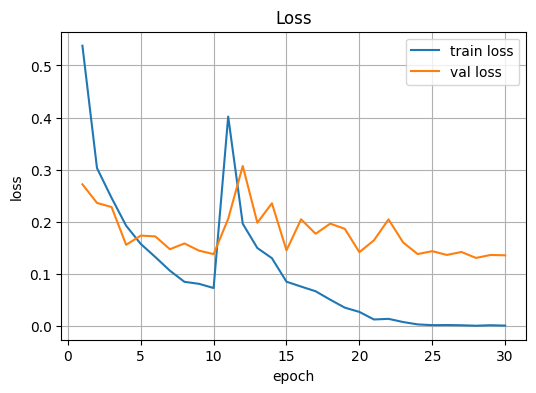

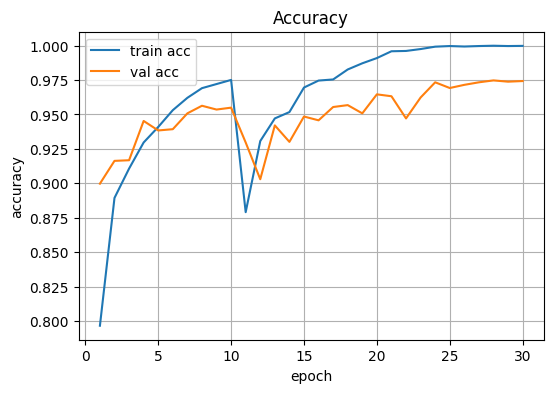

[TEST] overall acc = 0.9684
[[479   1   1   0   4   2]
 [  1 157   1   0   6   0]
 [  1   1 509   1   2   9]
 [  0   2   5 431   3   0]
 [  1   2   2   2 514   8]
 [  6   1  12   7   5 544]]


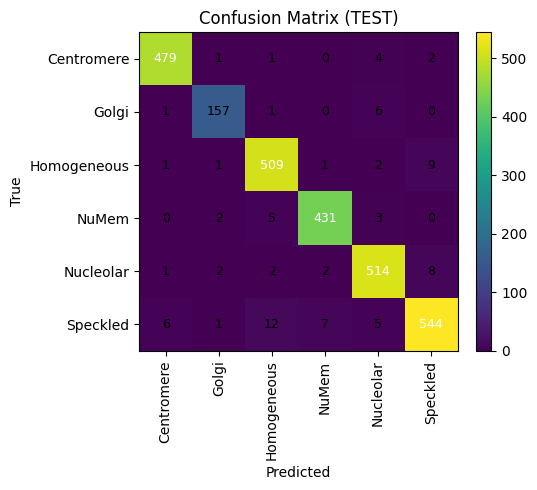

              precision    recall  f1-score   support

  Centromere     0.9816    0.9836    0.9826       487
       Golgi     0.9573    0.9515    0.9544       165
 Homogeneous     0.9604    0.9732    0.9668       523
       NuMem     0.9773    0.9773    0.9773       441
   Nucleolar     0.9625    0.9716    0.9671       529
    Speckled     0.9663    0.9461    0.9561       575

    accuracy                         0.9684      2720
   macro avg     0.9676    0.9672    0.9674      2720
weighted avg     0.9684    0.9684    0.9684      2720



In [ ]:
# Train (head->unfreeze) with progress/ETA + plots + confusion matrix + safe cleanup
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# Hyperparams
PHASE1_EPOCHS = 10
TOTAL_EPOCHS = 30
LR_HEAD = 2e-4
LR_FT = 2e-4
WD = 1e-4
ETA_MIN = 1e-6

# Build model
model = build_alexnet_for_classes(NUM_CLASSES, pretrained=True)

# History dict
hist = {"epoch": [], "tr_loss": [], "tr_acc": [], "val_loss": [], "val_acc": []}

freeze_features(model)
optimizer, scheduler = make_optimizer_scheduler(model, lr=LR_HEAD, wd=WD,
                                                t_max=PHASE1_EPOCHS, eta_min=ETA_MIN)

scaler = torch.amp.GradScaler(enabled=(AMP_DT=="cuda"))

# Phase 1 — head-only training
print(f"=== Phase 1: head-only for {PHASE1_EPOCHS} epochs ===")
t_global0 = time.time(); epochs_done = 0

for ep in range(1, PHASE1_EPOCHS+1):
    t0 = time.time()
    pbar = tqdm(train_loader, desc=f"P1 {ep}/{PHASE1_EPOCHS}", leave=False)
    model.train(); n, tot_loss, tot_acc = 0, 0.0, 0.0
    for xb, yb in pbar:
        xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast(AMP_DT, enabled=(AMP_DT=="cuda")):
            logits = model(xb); loss = criterion(logits, yb)
        scaler.scale(loss).backward(); scaler.step(optimizer); scaler.update()
        bs = xb.size(0); tot_loss += loss.item() * bs; tot_acc += accuracy(logits.detach(), yb) * bs; n += bs
        pbar.set_postfix(loss=f"{tot_loss/n:.4f}", acc=f"{tot_acc/n:.4f}")
    tr_loss, tr_acc = tot_loss/n, tot_acc/n

    vl_loss, vl_acc, _, _ = evaluate(model, val_loader)
    scheduler.step()

    epochs_done += 1
    elapsed = time.time() - t_global0
    eta_left = elapsed / max(epochs_done,1) * (TOTAL_EPOCHS - epochs_done)

    print_epoch_block("P1", ep, PHASE1_EPOCHS, tr_loss, tr_acc, vl_loss, vl_acc,
                      scheduler.get_last_lr()[0], time.time()-t0, eta_left)

    hist["epoch"].append(epochs_done)
    hist["tr_loss"].append(tr_loss); hist["tr_acc"].append(tr_acc)
    hist["val_loss"].append(vl_loss); hist["val_acc"].append(vl_acc)

# Phase 2 — unfreeze & fine-tune
unfreeze_features(model)
remain_epochs = max(TOTAL_EPOCHS - PHASE1_EPOCHS, 1)
optimizer, scheduler = make_optimizer_scheduler(model, lr=LR_FT, wd=WD,
                                                t_max=remain_epochs, eta_min=ETA_MIN)

print(f"=== Phase 2: unfreeze & fine-tune for {remain_epochs} epochs ===")
for i in range(1, remain_epochs+1):
    t0 = time.time()
    pbar = tqdm(train_loader, desc=f"P2 {i}/{remain_epochs}", leave=False)
    model.train(); n, tot_loss, tot_acc = 0, 0.0, 0.0
    for xb, yb in pbar:
        xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast(AMP_DT, enabled=(AMP_DT=="cuda")):
            logits = model(xb); loss = criterion(logits, yb)
        scaler.scale(loss).backward(); scaler.step(optimizer); scaler.update()
        bs = xb.size(0); tot_loss += loss.item() * bs; tot_acc += accuracy(logits.detach(), yb) * bs; n += bs
        pbar.set_postfix(loss=f"{tot_loss/n:.4f}", acc=f"{tot_acc/n:.4f}")
    tr_loss, tr_acc = tot_loss/n, tot_acc/n

    vl_loss, vl_acc, _, _ = evaluate(model, val_loader)
    scheduler.step()

    epochs_done += 1
    elapsed = time.time() - t_global0
    eta_left = elapsed / max(epochs_done,1) * (TOTAL_EPOCHS - epochs_done)

    print_epoch_block("P2", i, remain_epochs, tr_loss, tr_acc, vl_loss, vl_acc,
                      scheduler.get_last_lr()[0], time.time()-t0, eta_left)

    hist["epoch"].append(epochs_done)
    hist["tr_loss"].append(tr_loss); hist["tr_acc"].append(tr_acc)
    hist["val_loss"].append(vl_loss); hist["val_acc"].append(vl_acc)

print(f"\n[Train done] epochs={epochs_done} | total_time={fmt_time(time.time()-t_global0)}")


# Curves (Loss & Accuracy)
plt.figure(figsize=(6,4))
plt.plot(hist["epoch"], hist["tr_loss"], label="train loss")
plt.plot(hist["epoch"], hist["val_loss"], label="val loss")
plt.xlabel("epoch"); plt.ylabel("loss"); plt.title("Loss"); plt.grid(True); plt.legend(); plt.show()

plt.figure(figsize=(6,4))
plt.plot(hist["epoch"], hist["tr_acc"], label="train acc")
plt.plot(hist["epoch"], hist["val_acc"], label="val acc")
plt.xlabel("epoch"); plt.ylabel("accuracy"); plt.title("Accuracy"); plt.grid(True); plt.legend(); plt.show()

# Confusion matrix (prefer TEST; fallback VAL)
used, cm, report, acc_overall = test_confusion_or_fallback(
    model, test_loader, val_loader, NUM_CLASSES, le, id2class, extract_id_from_path
)
print(f"[{used}] overall acc = {acc_overall:.4f}")
print(cm)
plot_confusion_matrix(cm, classes=list(le.classes_), used=used, normalize=False)

print(report)


# 30 epochs. In the first 10 rounds, only the head is trained while the features are not. In the following 20 rounds, the features are trained. The learning rate for the head is 2e-4. lr-feature = 2e-4; Bilinear interpolation

=== Phase 1: head-only for 10 epochs ===


P1 1/10:   0%|          | 0/136 [00:00<?, ?it/s]

P1 1/10            | Train: loss 0.5195  acc 0.8093 | Valid: loss 0.2491  acc 0.9126 | LR 1.95e-04 | Epoch 0:00:07 | ETA 0:03:51


P1 2/10:   0%|          | 0/136 [00:00<?, ?it/s]

P1 2/10            | Train: loss 0.2580  acc 0.9070 | Valid: loss 0.2130  acc 0.9214 | LR 1.81e-04 | Epoch 0:00:07 | ETA 0:03:43


...

P2 18/20           | Train: loss 0.0007  acc 0.9999 | Valid: loss 0.1230  acc 0.9766 | LR 5.87e-06 | Epoch 0:00:07 | ETA 0:00:15


P2 19/20:   0%|          | 0/136 [00:00<?, ?it/s]

P2 19/20           | Train: loss 0.0008  acc 0.9998 | Valid: loss 0.1193  acc 0.9766 | LR 2.23e-06 | Epoch 0:00:08 | ETA 0:00:07


P2 20/20:   0%|          | 0/136 [00:00<?, ?it/s]

P2 20/20           | Train: loss 0.0006  acc 1.0000 | Valid: loss 0.1208  acc 0.9756 | LR 1.00e-06 | Epoch 0:00:07 | ETA 0:00:00

[Train done] epochs=30 | total_time=0:03:58


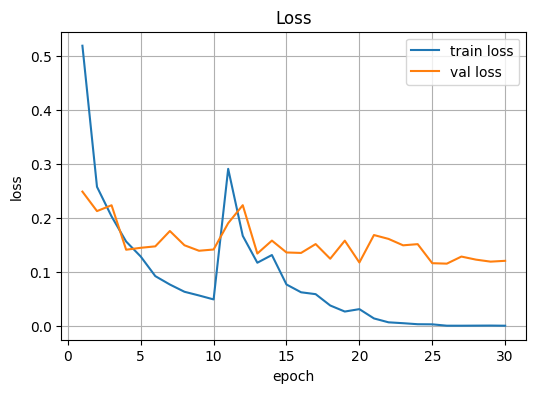

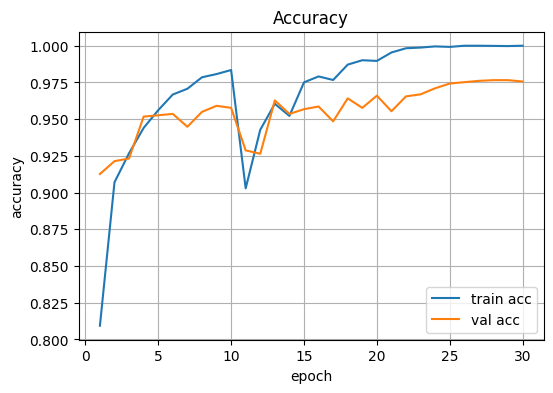

[TEST] overall acc = 0.9654
[[480   0   1   0   3   3]
 [  1 158   0   2   3   1]
 [  2   2 512   1   1   5]
 [  0   1   5 431   4   0]
 [  3   3   3   3 508   9]
 [  6   1  17   7   7 537]]


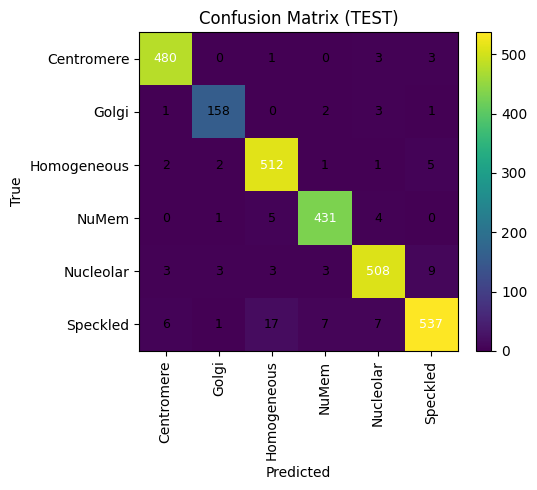

              precision    recall  f1-score   support

  Centromere     0.9756    0.9856    0.9806       487
       Golgi     0.9576    0.9576    0.9576       165
 Homogeneous     0.9517    0.9790    0.9651       523
       NuMem     0.9707    0.9773    0.9740       441
   Nucleolar     0.9658    0.9603    0.9630       529
    Speckled     0.9676    0.9339    0.9504       575

    accuracy                         0.9654      2720
   macro avg     0.9648    0.9656    0.9651      2720
weighted avg     0.9655    0.9654    0.9654      2720



In [ ]:
# Train (head->unfreeze) with progress/ETA + plots + confusion matrix + safe cleanup
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# Hyperparams
PHASE1_EPOCHS = 10
TOTAL_EPOCHS = 30
LR_HEAD = 2e-4
LR_FT = 2e-4
WD = 1e-4
ETA_MIN = 1e-6

# Build model
model = build_alexnet_for_classes(NUM_CLASSES, pretrained=True)

# History dict
hist = {"epoch": [], "tr_loss": [], "tr_acc": [], "val_loss": [], "val_acc": []}

freeze_features(model)
optimizer, scheduler = make_optimizer_scheduler(model, lr=LR_HEAD, wd=WD,
                                                t_max=PHASE1_EPOCHS, eta_min=ETA_MIN)

scaler = torch.amp.GradScaler(enabled=(AMP_DT=="cuda"))

# Phase 1 — head-only training
print(f"=== Phase 1: head-only for {PHASE1_EPOCHS} epochs ===")
t_global0 = time.time(); epochs_done = 0

for ep in range(1, PHASE1_EPOCHS+1):
    t0 = time.time()
    pbar = tqdm(train_loader, desc=f"P1 {ep}/{PHASE1_EPOCHS}", leave=False)
    model.train(); n, tot_loss, tot_acc = 0, 0.0, 0.0
    for xb, yb in pbar:
        xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast(AMP_DT, enabled=(AMP_DT=="cuda")):
            logits = model(xb); loss = criterion(logits, yb)
        scaler.scale(loss).backward(); scaler.step(optimizer); scaler.update()
        bs = xb.size(0); tot_loss += loss.item() * bs; tot_acc += accuracy(logits.detach(), yb) * bs; n += bs
        pbar.set_postfix(loss=f"{tot_loss/n:.4f}", acc=f"{tot_acc/n:.4f}")
    tr_loss, tr_acc = tot_loss/n, tot_acc/n

    vl_loss, vl_acc, _, _ = evaluate(model, val_loader)
    scheduler.step()

    epochs_done += 1
    elapsed = time.time() - t_global0
    eta_left = elapsed / max(epochs_done,1) * (TOTAL_EPOCHS - epochs_done)

    print_epoch_block("P1", ep, PHASE1_EPOCHS, tr_loss, tr_acc, vl_loss, vl_acc,
                      scheduler.get_last_lr()[0], time.time()-t0, eta_left)

    hist["epoch"].append(epochs_done)
    hist["tr_loss"].append(tr_loss); hist["tr_acc"].append(tr_acc)
    hist["val_loss"].append(vl_loss); hist["val_acc"].append(vl_acc)

# Phase 2 — unfreeze & fine-tune
unfreeze_features(model)
remain_epochs = max(TOTAL_EPOCHS - PHASE1_EPOCHS, 1)
optimizer, scheduler = make_optimizer_scheduler(model, lr=LR_FT, wd=WD,
                                                t_max=remain_epochs, eta_min=ETA_MIN)

print(f"=== Phase 2: unfreeze & fine-tune for {remain_epochs} epochs ===")
for i in range(1, remain_epochs+1):
    t0 = time.time()
    pbar = tqdm(train_loader, desc=f"P2 {i}/{remain_epochs}", leave=False)
    model.train(); n, tot_loss, tot_acc = 0, 0.0, 0.0
    for xb, yb in pbar:
        xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast(AMP_DT, enabled=(AMP_DT=="cuda")):
            logits = model(xb); loss = criterion(logits, yb)
        scaler.scale(loss).backward(); scaler.step(optimizer); scaler.update()
        bs = xb.size(0); tot_loss += loss.item() * bs; tot_acc += accuracy(logits.detach(), yb) * bs; n += bs
        pbar.set_postfix(loss=f"{tot_loss/n:.4f}", acc=f"{tot_acc/n:.4f}")
    tr_loss, tr_acc = tot_loss/n, tot_acc/n

    vl_loss, vl_acc, _, _ = evaluate(model, val_loader)
    scheduler.step()

    epochs_done += 1
    elapsed = time.time() - t_global0
    eta_left = elapsed / max(epochs_done,1) * (TOTAL_EPOCHS - epochs_done)

    print_epoch_block("P2", i, remain_epochs, tr_loss, tr_acc, vl_loss, vl_acc,
                      scheduler.get_last_lr()[0], time.time()-t0, eta_left)

    hist["epoch"].append(epochs_done)
    hist["tr_loss"].append(tr_loss); hist["tr_acc"].append(tr_acc)
    hist["val_loss"].append(vl_loss); hist["val_acc"].append(vl_acc)

print(f"\n[Train done] epochs={epochs_done} | total_time={fmt_time(time.time()-t_global0)}")


# Curves (Loss & Accuracy)
plt.figure(figsize=(6,4))
plt.plot(hist["epoch"], hist["tr_loss"], label="train loss")
plt.plot(hist["epoch"], hist["val_loss"], label="val loss")
plt.xlabel("epoch"); plt.ylabel("loss"); plt.title("Loss"); plt.grid(True); plt.legend(); plt.show()

plt.figure(figsize=(6,4))
plt.plot(hist["epoch"], hist["tr_acc"], label="train acc")
plt.plot(hist["epoch"], hist["val_acc"], label="val acc")
plt.xlabel("epoch"); plt.ylabel("accuracy"); plt.title("Accuracy"); plt.grid(True); plt.legend(); plt.show()

# Confusion matrix (prefer TEST; fallback VAL)
used, cm, report, acc_overall = test_confusion_or_fallback(
    model, test_loader, val_loader, NUM_CLASSES, le, id2class, extract_id_from_path
)
print(f"[{used}] overall acc = {acc_overall:.4f}")
print(cm)
plot_confusion_matrix(cm, classes=list(le.classes_), used=used, normalize=False)

print(report)


# 30 epochs. In the first 10 rounds, only the head is trained while the features are not. In the following 20 rounds, the features are trained. The learning rate for the head is 3e-4. lr-feature = 2e-4; BICUBIC Bicubic Interpolation

=== Phase 1: head-only for 10 epochs ===


P1 1/10:   0%|          | 0/136 [00:00<?, ?it/s]

P1 1/10            | Train: loss 0.5083  acc 0.8150 | Valid: loss 0.2437  acc 0.9131 | LR 1.95e-04 | Epoch 0:00:12 | ETA 0:06:11


P1 2/10:   0%|          | 0/136 [00:00<?, ?it/s]

P1 2/10            | Train: loss 0.2584  acc 0.9091 | Valid: loss 0.2152  acc 0.9232 | LR 1.81e-04 | Epoch 0:00:12 | ETA 0:05:58


...

P2 18/20           | Train: loss 0.0005  acc 1.0000 | Valid: loss 0.1384  acc 0.9729 | LR 5.87e-06 | Epoch 0:00:12 | ETA 0:00:25


P2 19/20:   0%|          | 0/136 [00:00<?, ?it/s]

P2 19/20           | Train: loss 0.0005  acc 1.0000 | Valid: loss 0.1384  acc 0.9738 | LR 2.23e-06 | Epoch 0:00:12 | ETA 0:00:12


P2 20/20:   0%|          | 0/136 [00:00<?, ?it/s]

P2 20/20           | Train: loss 0.0008  acc 0.9998 | Valid: loss 0.1404  acc 0.9743 | LR 1.00e-06 | Epoch 0:00:12 | ETA 0:00:00

[Train done] epochs=30 | total_time=0:06:22


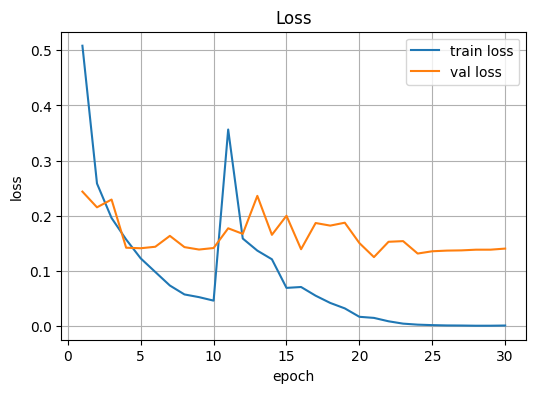

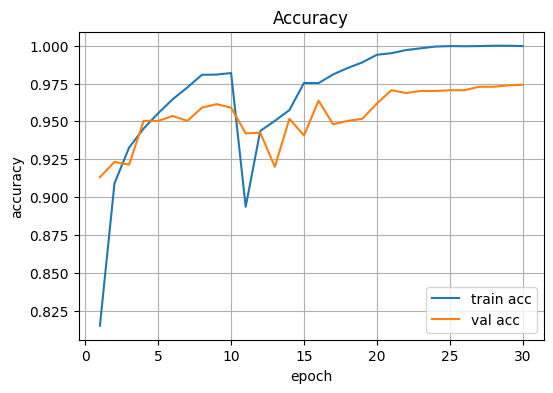

[TEST] overall acc = 0.9654
[[476   0   0   0   4   7]
 [  3 153   1   1   7   0]
 [  1   0 511   0   1  10]
 [  0   0   7 430   4   0]
 [  1   2   4   1 511  10]
 [  6   1  10   7   6 545]]


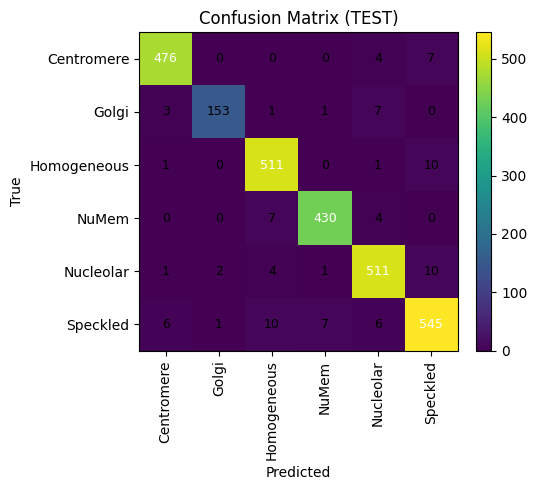

              precision    recall  f1-score   support

  Centromere     0.9774    0.9774    0.9774       487
       Golgi     0.9808    0.9273    0.9533       165
 Homogeneous     0.9587    0.9771    0.9678       523
       NuMem     0.9795    0.9751    0.9773       441
   Nucleolar     0.9587    0.9660    0.9623       529
    Speckled     0.9528    0.9478    0.9503       575

    accuracy                         0.9654      2720
   macro avg     0.9680    0.9618    0.9647      2720
weighted avg     0.9655    0.9654    0.9654      2720



In [ ]:
# Train (head->unfreeze) with progress/ETA + plots + confusion matrix + safe cleanup
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# Hyperparams
PHASE1_EPOCHS = 10
TOTAL_EPOCHS = 30
LR_HEAD = 2e-4
LR_FT = 2e-4
WD = 1e-4
ETA_MIN = 1e-6

# Build model
model = build_alexnet_for_classes(NUM_CLASSES, pretrained=True)

# History dict
hist = {"epoch": [], "tr_loss": [], "tr_acc": [], "val_loss": [], "val_acc": []}

freeze_features(model)
optimizer, scheduler = make_optimizer_scheduler(model, lr=LR_HEAD, wd=WD,
                                                t_max=PHASE1_EPOCHS, eta_min=ETA_MIN)

scaler = torch.amp.GradScaler(enabled=(AMP_DT=="cuda"))

# Phase 1 — head-only training
print(f"=== Phase 1: head-only for {PHASE1_EPOCHS} epochs ===")
t_global0 = time.time(); epochs_done = 0

for ep in range(1, PHASE1_EPOCHS+1):
    t0 = time.time()
    pbar = tqdm(train_loader, desc=f"P1 {ep}/{PHASE1_EPOCHS}", leave=False)
    model.train(); n, tot_loss, tot_acc = 0, 0.0, 0.0
    for xb, yb in pbar:
        xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast(AMP_DT, enabled=(AMP_DT=="cuda")):
            logits = model(xb); loss = criterion(logits, yb)
        scaler.scale(loss).backward(); scaler.step(optimizer); scaler.update()
        bs = xb.size(0); tot_loss += loss.item() * bs; tot_acc += accuracy(logits.detach(), yb) * bs; n += bs
        pbar.set_postfix(loss=f"{tot_loss/n:.4f}", acc=f"{tot_acc/n:.4f}")
    tr_loss, tr_acc = tot_loss/n, tot_acc/n

    vl_loss, vl_acc, _, _ = evaluate(model, val_loader)
    scheduler.step()

    epochs_done += 1
    elapsed = time.time() - t_global0
    eta_left = elapsed / max(epochs_done,1) * (TOTAL_EPOCHS - epochs_done)

    print_epoch_block("P1", ep, PHASE1_EPOCHS, tr_loss, tr_acc, vl_loss, vl_acc,
                      scheduler.get_last_lr()[0], time.time()-t0, eta_left)

    hist["epoch"].append(epochs_done)
    hist["tr_loss"].append(tr_loss); hist["tr_acc"].append(tr_acc)
    hist["val_loss"].append(vl_loss); hist["val_acc"].append(vl_acc)

# Phase 2 — unfreeze & fine-tune
unfreeze_features(model)
remain_epochs = max(TOTAL_EPOCHS - PHASE1_EPOCHS, 1)
optimizer, scheduler = make_optimizer_scheduler(model, lr=LR_FT, wd=WD,
                                                t_max=remain_epochs, eta_min=ETA_MIN)

print(f"=== Phase 2: unfreeze & fine-tune for {remain_epochs} epochs ===")
for i in range(1, remain_epochs+1):
    t0 = time.time()
    pbar = tqdm(train_loader, desc=f"P2 {i}/{remain_epochs}", leave=False)
    model.train(); n, tot_loss, tot_acc = 0, 0.0, 0.0
    for xb, yb in pbar:
        xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast(AMP_DT, enabled=(AMP_DT=="cuda")):
            logits = model(xb); loss = criterion(logits, yb)
        scaler.scale(loss).backward(); scaler.step(optimizer); scaler.update()
        bs = xb.size(0); tot_loss += loss.item() * bs; tot_acc += accuracy(logits.detach(), yb) * bs; n += bs
        pbar.set_postfix(loss=f"{tot_loss/n:.4f}", acc=f"{tot_acc/n:.4f}")
    tr_loss, tr_acc = tot_loss/n, tot_acc/n

    vl_loss, vl_acc, _, _ = evaluate(model, val_loader)
    scheduler.step()

    epochs_done += 1
    elapsed = time.time() - t_global0
    eta_left = elapsed / max(epochs_done,1) * (TOTAL_EPOCHS - epochs_done)

    print_epoch_block("P2", i, remain_epochs, tr_loss, tr_acc, vl_loss, vl_acc,
                      scheduler.get_last_lr()[0], time.time()-t0, eta_left)

    hist["epoch"].append(epochs_done)
    hist["tr_loss"].append(tr_loss); hist["tr_acc"].append(tr_acc)
    hist["val_loss"].append(vl_loss); hist["val_acc"].append(vl_acc)

print(f"\n[Train done] epochs={epochs_done} | total_time={fmt_time(time.time()-t_global0)}")


# Curves (Loss & Accuracy)
plt.figure(figsize=(6,4))
plt.plot(hist["epoch"], hist["tr_loss"], label="train loss")
plt.plot(hist["epoch"], hist["val_loss"], label="val loss")
plt.xlabel("epoch"); plt.ylabel("loss"); plt.title("Loss"); plt.grid(True); plt.legend(); plt.show()

plt.figure(figsize=(6,4))
plt.plot(hist["epoch"], hist["tr_acc"], label="train acc")
plt.plot(hist["epoch"], hist["val_acc"], label="val acc")
plt.xlabel("epoch"); plt.ylabel("accuracy"); plt.title("Accuracy"); plt.grid(True); plt.legend(); plt.show()

# Confusion matrix (prefer TEST; fallback VAL)
used, cm, report, acc_overall = test_confusion_or_fallback(
    model, test_loader, val_loader, NUM_CLASSES, le, id2class, extract_id_from_path
)
print(f"[{used}] overall acc = {acc_overall:.4f}")
print(cm)
plot_confusion_matrix(cm, classes=list(le.classes_), used=used, normalize=False)

print(report)
